# process directed forgetting fMRI data 

clip study test nii.gz files so they're the same length (based on events.tsv) such that we can feed into tc.timecorr to get correlation matrices for forget vs remember conditions 

### note: 
nii.gz in TRs not seconds (conversion: 1 TR = 2 sec)


---
**events.tsv**
- onset: this tells us when the event starts (in seconds) relative to the start of the neuroimaging file
- duration: this tells us how long the given event lasts (should always be 3 seconds)
- list: are we studying list A or list B?
- word: what word is the participant looking at now?
- memory cue: will the participant be told to remember or forget the list A words on this run?  (not relevant for list B words)

In [152]:
import pandas as pd
import numpy as np
import nibabel as nib
import nltools 
from bids import BIDSLayout
import timecorr as tc


In [153]:
# setup 
data_dir = "../../data-cdl"
layout = BIDSLayout(data_dir, derivatives=True)
subs = layout.get_subjects() 

c:\Users\mgnli\anaconda3\envs\timecorr\lib\site-packages\bids\layout\validation.py:131: UserWarning: Derivative indexing was requested, but no valid derivative datasets were found in the specified locations ([WindowsPath('c:/Users/mgnli/CDL/directed-forgetting-network-dynamics/code/../../data-cdl/derivatives')]). Note that all BIDS-Derivatives datasets must meet all the requirements for BIDS-Raw datasets (a common problem is to fail to include a 'dataset_description.json' file in derivatives datasets).
Example contents of 'dataset_description.json':
{"Name": "Example dataset", "BIDSVersion": "1.0.2", "GeneratedBy": [{"Name": "Example pipeline"}]}
  warnings.warn("Derivative indexing was requested, but no valid "


In [154]:
"""
checks the difference timing between the onset of the last word of list A and the first word of list B is 14 seconds (approximately)
input: 
    df - pandas dataframe of one run from one subject
    run_ID - str (for error handling)
    sub_ID - str (for error handling)
output: 
    n/a
"""
def check_timing(df, run_ID, sub_ID): 
    last_listA_word_onset = df[(df["list"]=="A")].iloc[-1]["onset"]
    first_listB_word_onset = df[df["list"]=="B"].iloc[0]["onset"]
    
    difference_in_onset = round(first_listB_word_onset) - round(last_listA_word_onset)

    if round(difference_in_onset) != 14: 
        print(f"err: sub-{sub_ID} run-{run_ID} timing gap between onset of last word of list A and first word of list B is {difference_in_onset}; expected=14")

In [155]:
"""
calculate when the memory cue (remember/forget) appears in TRs
input: 
    df - pandas dataframe of one run from one subject
output: 
    cue_timing_trs - int 
"""
def get_cue_timing(df): 
    last_listA_word_onset = df[(df["list"]=="A")].iloc[-1]["onset"]
    cue_timing_seconds = round(last_listA_word_onset) + 6  
    cue_timing_trs = round(cue_timing_seconds / 2)

    return cue_timing_trs

In [156]:
"""
processes one events.tsv file from one run from one subject and returns tsv as a pandas dataframe and forget/remember cue 

input: 
    run_ID - str 
    sub_ID - str (str is two chars, consisting of ints)
output: 
    sub_run_df - pandas df
    cue - str (forget or remember)
    cue_timing_trs - int of when cue appears
"""
def read_tsv(run_ID, sub_ID): 
    sub_run_df = pd.read_csv(f'{data_dir}/sub-{sub_ID}/func/sub-{sub_ID}_task-StudyTest_run-{run_ID}_events.tsv', sep='\t')

    cue = sub_run_df["memory_cue"][0]
    # check cue doesn't change for that run 
    for e in sub_run_df["memory_cue"]: 
        # print(e)
        if not ((e == cue) or (pd.isna(e))):
            cue = None 
            print("err: in events.tsv for sub", sub_ID, " run",run_ID)

    # check_timing(sub_run_df, run_ID, sub_ID)

    cue_timing = get_cue_timing(sub_run_df)
    
    return sub_run_df, cue, cue_timing

In [157]:
"""
processes all events.tsv files from one subject and returns pandas dataframe of tsvs and forget/remember cues 

input: 
    sub_ID - str (str is two chars, consisting of ints)
output: 
    sub_dfs - array of pandas dataframes 
    sub_cues (forget/remember) -  array of str
    sub_cue_timing - array of ints 
    
    run # = index + 1 (e.g., run 1 = index 0)
"""
def read_one_sub_tsvs(sub_ID): 
    sub_dfs = []
    sub_cues = []
    sub_cue_timing = []
    
    subj_niftis = layout.get(subject=sub_ID, return_type='file', task="StudyTest", extension='nii.gz')

    for run in range(1, len(subj_niftis)+1):
        run_ID = f"{run:02}"

        sub_run_df, cue, cue_timing = read_tsv(run_ID, sub_ID)

        sub_cue_timing.append(cue_timing)
        sub_dfs.append(sub_run_df)
        sub_cues.append(cue)

    return sub_dfs, sub_cues, sub_cue_timing

In [158]:
"""
processes all events.tsv files from all subjects and returns nested array of subjects and their pandas dataframes and forget/remember cues 

input: 
    subs - array of str 
output: 
    dfs - nested array; outer array (index i = sub i-1) & inner arrays (sub i-1 = array of pandas dataframes where index e = run e - 1)
        since subjects and runs are indexed at 1 
    cues - nested array of strs (similar to dfs) 
    timings - nested array of ints (similar to dfs)
"""
def read_all_subs_tsvs(subs): 
    dfs = []
    cues = []
    timings = []

    for sub_ID in subs: 
        sub_dfs, sub_cues, sub_cue_timing = read_one_sub_tsvs(sub_ID)
        
        dfs.append(sub_dfs)
        cues.append(sub_cues)
        timings.append(sub_cue_timing)

    return dfs, cues, timings

In [159]:
def main(): 
    # read all tsvs for all subjects
    dfs, cues, timings = read_all_subs_tsvs(subs)

    # test: read_all_subs_tsvs() 
    for i in range(24): 
      if len(dfs[i]) != 8: 
            print("fail: read_all_subs_tsvs() didn't read dfs correctly")
    if len(cues[i]) != 8: 
        print("fail: read_all_subs_tsvs() didn't read cues correctly")
    if len(timings[i]) != 8: 
        print("fail: read_all_subs_tsvs() didn't read cue timings correctly")


main()

In [160]:
## TODO: NIFTI  

## pseudo for different cue timings

# find # TRs 
# convert to seconds 
# find run with latest onset for first stimulus 
# pad other runs with zeros so that first stimulus onset time matches 
# check intervals between stimulus is the same such that the other stimuli also match up  

In [161]:
# nested array of niftis; outer array (index i = sub i-1) & inner arrays (sub i-1 = array of nifti files where index e = run e - 1)
niftis = [] 
data_shapes = set()

# load data 
for sub_ID in subs: 
    subj_niftis = []
    subj_nifti_filenames = layout.get(subject=sub_ID, return_type='file', task="StudyTest", extension='nii.gz') # array of 8 runs for given sun_ID

for nifti in subj_nifti_filenames: 
    data = nib.load(nifti)
    subj_niftis.append(data)
    data_shapes.add(data.shape)

niftis.append(subj_niftis)

print(data_shapes)  # {(64, 64, 36, 142)} -- only one shape? 


{(64, 64, 36, 142)}


summary of fMRI data libs
- pybids - navigate and query fMRI datasets that conform to BIDS 
    - BIDSLayout() creates object of BIDSFile class
        - .get() gets files according to parameters     
- nibabel - read, write to neuroimaging files 
    - nib.load()
- nilearn - visualize (and analyze) neuroimaging data 
    - plot_anat() 
    - plot_glass_brain() 
- nltools - analyze (and visualize) neuroimaging data 
    - Brain_Data() -- can also be converted back to nifti 

In [170]:
from nltools import Brain_Data
import os

t1w = Brain_Data("../../data-cdl/sub-01/anat/sub-01_T1w.nii.gz")

<class 'nltools.data.brain_data.Brain_Data'>


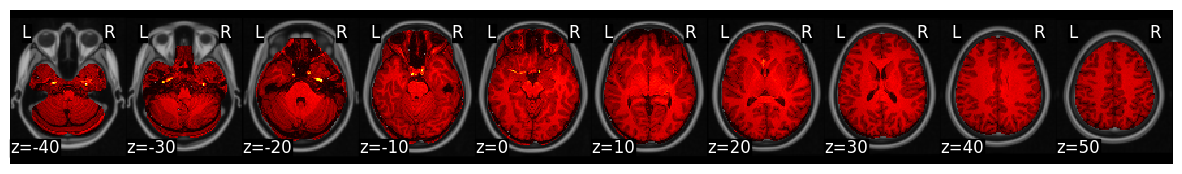

In [173]:
print(type(t1w))

t1w.plot()

In [ ]:
import timecorr as tc
import numpy as np

x = [np.random.randn(100, 10) for _ in range(10)] #make a fake dataset with 100 timepoints and 10 features
corrs = tc.timecorr(x, cfun=tc.isfc, combine=tc.corrmean_combine)  # run timecorr on the dataset to compute a correlation matrix for each timepoint

In [175]:
print(len(corrs))

100
